In [32]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
import random

Create a dataset of at least 200 students containing:
student_id, math, science, english, attendance_percent


In [33]:
data=[]
fake=Faker()
for i in range(200):
    data.append({
        "student_id":fake.uuid4(),
        "math":random.randint(1,50),
        "science":random.randint(1,50),
        "english":random.randint(1,50),
        "attendance_percent":random.randint(1,100)
    })
df=pd.DataFrame(data)
df.to_csv("Student_Record.csv",index=False)
df.head(10)

,student_id,math,science,english,attendance_percent
0,5854997c-f737-4695-a0a4-b568dacc5a4a,9,20,45,47
1,627303fa-4d62-4681-a824-c76aac18417c,5,45,30,99
2,7a559566-8c39-4494-b031-5976d32e8561,44,26,18,27
3,2c203ac0-7ad7-4ca6-ae54-17c8e6632d45,49,23,11,98
4,9b2ce422-5247-49ae-bb9f-7aaf854f6a5f,16,6,43,27
5,8ef8d889-6286-49f5-9dda-0e2b15159dcd,11,30,2,77
6,c20ba96d-b346-4c57-9e37-72a1a10484f4,36,16,31,94
7,31ec7fb8-c5b4-491c-9f10-37bc7b29f0cc,30,18,27,72
8,64c59d13-14d9-47e6-b498-4eabf5e14408,10,1,47,60
9,571ebd7e-ac85-49f6-a91b-64c408fe5e4f,1,43,10,48


Using Pandas:
Compute total and average scores.

In [34]:
df["total_Score"]=df.groupby("student_id")[["math","science","english"]].transform('sum').sum(axis=1)
print(df.head(5))

                             student_id  math  science  english  \
0  5854997c-f737-4695-a0a4-b568dacc5a4a     9       20       45   
1  627303fa-4d62-4681-a824-c76aac18417c     5       45       30   
2  7a559566-8c39-4494-b031-5976d32e8561    44       26       18   
3  2c203ac0-7ad7-4ca6-ae54-17c8e6632d45    49       23       11   
4  9b2ce422-5247-49ae-bb9f-7aaf854f6a5f    16        6       43   

   attendance_percent  total_Score  
0                  47           74  
1                  99           80  
2                  27           88  
3                  98           83  
4                  27           65  


Classify students based on performance

In [35]:
df["avg_score"]=df[["math","science","english"]].mean(axis=1)
df.head(5)

,student_id,math,science,english,attendance_percent,total_Score,avg_score
0,5854997c-f737-4695-a0a4-b568dacc5a4a,9,20,45,47,74,24.666667
1,627303fa-4d62-4681-a824-c76aac18417c,5,45,30,99,80,26.666667
2,7a559566-8c39-4494-b031-5976d32e8561,44,26,18,27,88,29.333333
3,2c203ac0-7ad7-4ca6-ae54-17c8e6632d45,49,23,11,98,83,27.666667
4,9b2ce422-5247-49ae-bb9f-7aaf854f6a5f,16,6,43,27,65,21.666667


In [36]:
# classify based on avg score
bins=[15,20,30,40]
labels=["poor","Good","Excellent"]
df["performance"]=pd.cut(df["avg_score"],labels=labels,bins=bins)
df.head(10)


,student_id,math,science,english,attendance_percent,total_Score,avg_score,performance
0,5854997c-f737-4695-a0a4-b568dacc5a4a,9,20,45,47,74,24.666667,Good
1,627303fa-4d62-4681-a824-c76aac18417c,5,45,30,99,80,26.666667,Good
2,7a559566-8c39-4494-b031-5976d32e8561,44,26,18,27,88,29.333333,Good
3,2c203ac0-7ad7-4ca6-ae54-17c8e6632d45,49,23,11,98,83,27.666667,Good
4,9b2ce422-5247-49ae-bb9f-7aaf854f6a5f,16,6,43,27,65,21.666667,Good
5,8ef8d889-6286-49f5-9dda-0e2b15159dcd,11,30,2,77,43,14.333333,NaN
6,c20ba96d-b346-4c57-9e37-72a1a10484f4,36,16,31,94,83,27.666667,Good
7,31ec7fb8-c5b4-491c-9f10-37bc7b29f0cc,30,18,27,72,75,25.000000,Good
8,64c59d13-14d9-47e6-b498-4eabf5e14408,10,1,47,60,58,19.333333,poor
9,571ebd7e-ac85-49f6-a91b-64c408fe5e4f,1,43,10,48,54,18.000000,poor


Using NumPy:
Apply weighted scoring techniques.

In [37]:
weight=33.33
df["weighted_score"]=(df["math"]*weight+df["science"]*weight+df["english"]*weight)
df.head(10)

,student_id,math,science,english,attendance_percent,total_Score,avg_score,performance,weighted_score
0,5854997c-f737-4695-a0a4-b568dacc5a4a,9,20,45,47,74,24.666667,Good,2466.42
1,627303fa-4d62-4681-a824-c76aac18417c,5,45,30,99,80,26.666667,Good,2666.40
2,7a559566-8c39-4494-b031-5976d32e8561,44,26,18,27,88,29.333333,Good,2933.04
3,2c203ac0-7ad7-4ca6-ae54-17c8e6632d45,49,23,11,98,83,27.666667,Good,2766.39
4,9b2ce422-5247-49ae-bb9f-7aaf854f6a5f,16,6,43,27,65,21.666667,Good,2166.45
5,8ef8d889-6286-49f5-9dda-0e2b15159dcd,11,30,2,77,43,14.333333,NaN,1433.19
6,c20ba96d-b346-4c57-9e37-72a1a10484f4,36,16,31,94,83,27.666667,Good,2766.39
7,31ec7fb8-c5b4-491c-9f10-37bc7b29f0cc,30,18,27,72,75,25.000000,Good,2499.75
8,64c59d13-14d9-47e6-b498-4eabf5e14408,10,1,47,60,58,19.333333,poor,1933.14
9,571ebd7e-ac85-49f6-a91b-64c408fe5e4f,1,43,10,48,54,18.000000,poor,1799.82


Standardize subject scores

In [38]:
df["math_std"]=(df["math"]-np.mean(df["math"]))/np.std(df["math"])
df['english_std']=(df['english']-np.mean(df['english']))/np.std(df['english'])
df['science_std']=(df['science']-np.mean(df['science']))/np.std(df['science'])
df.head(10)

,student_id,math,science,english,attendance_percent,total_Score,avg_score,performance,weighted_score,math_std,english_std,science_std
0,5854997c-f737-4695-a0a4-b568dacc5a4a,9,20,45,47,74,24.666667,Good,2466.42,-1.137936,1.448673,-0.289118
1,627303fa-4d62-4681-a824-c76aac18417c,5,45,30,99,80,26.666667,Good,2666.40,-1.426752,0.358899,1.497768
2,7a559566-8c39-4494-b031-5976d32e8561,44,26,18,27,88,29.333333,Good,2933.04,1.389206,-0.512921,0.139735
3,2c203ac0-7ad7-4ca6-ae54-17c8e6632d45,49,23,11,98,83,27.666667,Good,2766.39,1.750227,-1.021482,-0.074692
4,9b2ce422-5247-49ae-bb9f-7aaf854f6a5f,16,6,43,27,65,21.666667,Good,2166.45,-0.632508,1.303370,-1.289775


Using a visualization library:
Compare subject-wise performance.

math       24.760
science    24.045
english    25.060
dtype: float64


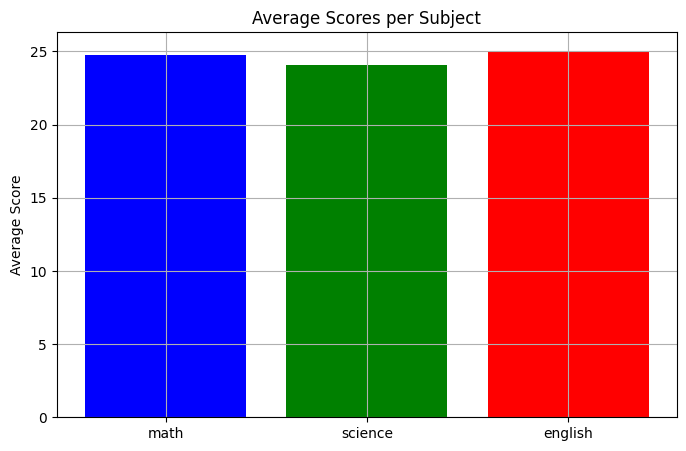

In [39]:
subjects = ["math","science","english"]
subject_avg = df[subjects].mean()
print(subject_avg)
plt.figure(figsize=(8,5))
plt.bar(subject_avg.index, subject_avg.values, color=["blue","green","red"])
plt.title("Average Scores per Subject")
plt.ylabel("Average Score")
plt.grid()
plt.show()

Analyze attendance vs academic performance

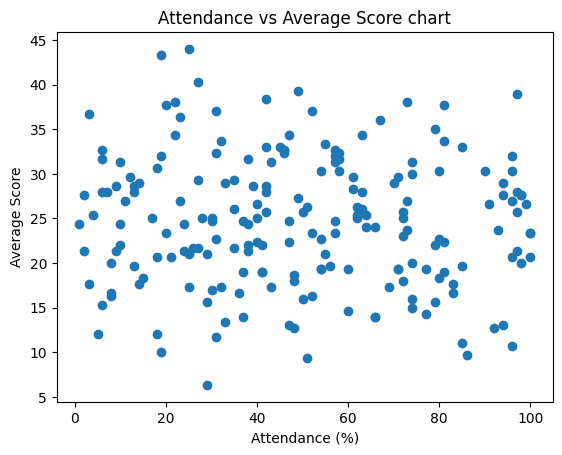

In [40]:
plt.scatter(df['attendance_percent'], df['avg_score'])
plt.title("Attendance vs Average Score chart")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.show()